# Laboratorio de regresión - 3

## Análisis exploratorio de datos y limpieza

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 05/09/2026       |
| **Expediente** | 757806           |

En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?

Con un análisis exploratorio. Antes de proponer cualquier modelo hay que graficar los datos
y ver cómo se comporta cada factor contra la variable que se quiere predecir

Si la nube de puntos se ve como una recta se propone un modelo lineal, si se ve curveada se
piensa en meter términos cuadráticos o de otro grado. También sirve ver las correlaciones para
saber cuáles factores traen información y cuáles no

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [1]:
# Cargar los datos del corazón

import pandas as pd

datos = pd.read_csv("Heart Prediction Quantum Dataset.csv")

print(datos)

     Age     Gender BloodPressure  Cholesterol  HeartRate  HeartDisease
0     68  Hombre           105.00          191        107             1
1     58      Mujer         97.00          249         89             0
2     44      Mujer         93.00          190         82             1
3     72  Hombre            93.00          183        101             1
4     37      Mujer        145.00          166        103             1
..   ...        ...           ...          ...        ...           ...
495   34      Mujer        126.00          292        116             0
496   41      Mujer        164.00          248        114             0
497   45     Hombre        159.00          175         75             0
498   55      Mujer        107.00          157        101             1
499   55      Mujer        174.00          249         89             0

[500 rows x 6 columns]


In [2]:
datos.shape # Renglones y columnas

(500, 6)

In [3]:
datos.dtypes # Tipo de dato de cada factor

Age               int64
Gender           object
BloodPressure    object
Cholesterol       int64
HeartRate         int64
HeartDisease      int64
dtype: object

Son 500 renglones y 6 columnas

Los factores son Age, Gender, BloodPressure, Cholesterol y HeartRate, y la variable que se
quiere predecir es HeartDisease

Age, Cholesterol, HeartRate y HeartDisease los leyó como enteros pero Gender y BloodPressure
los leyó como texto, y BloodPressure debería ser un número

Para cada factor, escribe qué significa cada variable.
- ¿Qué tipo de datos se observaron?
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- ¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.

Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.

- **Age** es la edad del paciente en años, es numérica entera. Se esperarían valores de unos
20 a 90 años, nunca negativos
- **Gender** es el sexo del paciente, es categórica no ordinal porque hombre no es ni mayor ni
menor que mujer. Solo debería tener dos valores
- **BloodPressure** es la presión arterial sistólica en mmHg, es numérica flotante. Lo normal
anda por debajo de 120, arriba de 130 ya se considera hipertensión y pasando de 180 es una
urgencia, así que se esperaría un rango como de 90 a 180
- **Cholesterol** es el colesterol total en mg/dL, es numérica entera. Menos de 200 es deseable,
de 200 a 239 es límite y de 240 para arriba es alto, se esperaría algo entre 150 y 300
- **HeartRate** es la frecuencia cardiaca en latidos por minuto, es numérica entera. En reposo
lo normal para un adulto es de 60 a 100
- **HeartDisease** dice si el paciente tiene enfermedad del corazón, es categórica no ordinal y
solo puede valer 0 o 1

A partir de lo investigado, describe el dataset con tus palabras.

In [4]:
datos["HeartDisease"].value_counts() # Cuántos enfermos y cuántos sanos

HeartDisease
1    300
0    200
Name: count, dtype: int64

Es un conjunto de 500 pacientes donde a cada uno se le midió la edad, el sexo, la presión
arterial, el colesterol y el ritmo cardiaco, y se anotó si tiene o no enfermedad del corazón

300 pacientes sí tienen la enfermedad y 200 no, o sea que está algo desbalanceado hacia los
enfermos. La idea del dataset es usar los cinco factores para predecir HeartDisease

En el archivo no viene quién juntó los datos ni en qué año ni en qué hospital, y viendo los
valores se nota que son inventados por computadora y no medidos a pacientes de verdad

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución. 

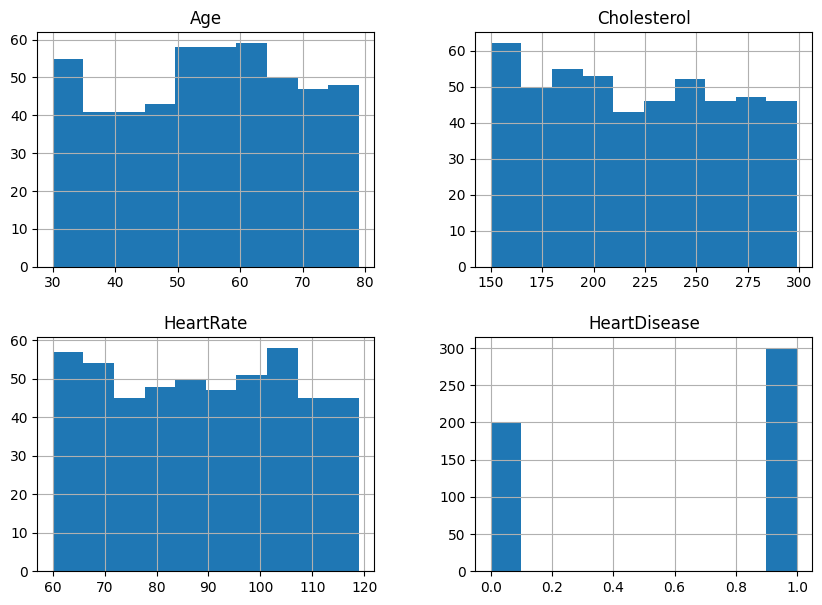

In [5]:
# Histograma de cada factor

import matplotlib.pyplot as plt

datos.hist(figsize=(10, 7))
plt.show()

Solo salieron cuatro histogramas de los seis factores

Gender y BloodPressure no aparecen porque están guardados como texto y no como número, así que
pandas ni los grafica

¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?

Age va de 30 a 79, Cholesterol de 150 a 299 y HeartRate de 60 a 119, o sea que todos caen
dentro de rangos que sí existen en la vida real. No hay edades negativas ni valores imposibles

Lo que sí está mal es que las tres distribuciones se ven planas, todas las barras miden casi lo
mismo. En pacientes de verdad la edad o el colesterol se amontonarían en el centro haciendo una
campana, que salgan parejas confirma que los datos fueron generados en computadora

Los problemas más grandes son los otros dos factores. BloodPressure quedó como texto porque hay
renglones con coma en lugar de punto decimal, y Gender está escrito de muchas formas distintas
con mayúsculas, espacios y errores de dedo. Esos sí son errores de captura y no casos reales, se
tienen que limpiar

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.

In [6]:
# Cambiar el punto decimal europeo por el americano

datos["BloodPressure"] = datos["BloodPressure"].str.replace(",", ".")
datos["BloodPressure"] = pd.to_numeric(datos["BloodPressure"])

datos["BloodPressure"].dtype

dtype('float64')

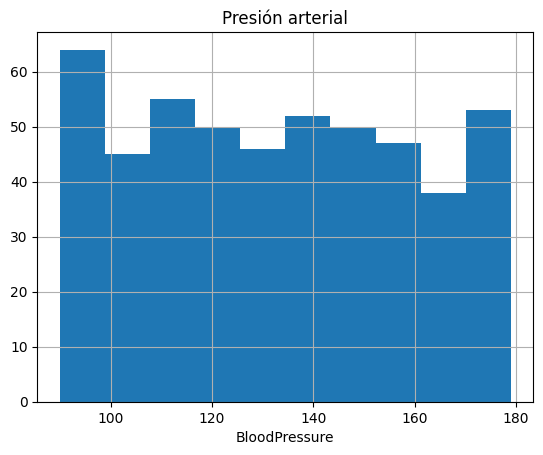

In [7]:
# Histograma de la presión ya corregida

datos["BloodPressure"].hist()
plt.xlabel("BloodPressure")
plt.title("Presión arterial")
plt.show()

Ya quedó como float64 y ahora sí se puede graficar

La presión va de 90 a 179 y sale igual de plana que las demás

La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".

In [8]:
datos["Gender"].unique() # Todas las formas en que se escribió el sexo

array(['Hombre   ', 'Mujer', 'ombre', 'mujer', 'MUjer', 'MUJER', 'Mujer{',
       'Hombre}', 'Hombre'], dtype=object)

Salieron 9 formas diferentes para nada más dos categorías

Para hombre están 'Hombre   ' con espacios al final, 'Hombre}' con una llave, 'Hombre' bien
escrito y 'ombre' al que se le olvidó la h

Para mujer están 'Mujer', 'mujer', 'MUjer', 'MUJER' y 'Mujer{' con llave

La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.

In [9]:
# Todo a minúsculas para quitar la variación de mayúsculas

genero = datos["Gender"].str.lower()

genero.unique()

array(['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre'],
      dtype=object)

Con las minúsculas bajamos de 9 formas a 6

Ya quedaron 'hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}' y 'hombre'. Lo que falta de
limpiar son los espacios, las llaves y el error de dedo

Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.

In [10]:
# Quitar los espacios y las llaves de la derecha

genero = genero.str.rstrip(" {}")

genero.unique()

array(['hombre', 'mujer', 'ombre'], dtype=object)

Quedaron solo 3 formas, 'hombre', 'mujer' y 'ombre'

Nada más falta el error de dedo de la h

Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".

In [11]:
# Corregir la h que le falta a ombre

genero[genero == "ombre"] = "hombre"

genero.unique()

array(['hombre', 'mujer'], dtype=object)

Ya nada más quedaron las dos categorías que debían ser desde el principio

Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").

In [12]:
# Asignar hombre igual a 1 y mujer igual a 0

genero = (genero == "hombre").astype(int)

genero.unique()

array([1, 0])

Quedaron 1 y 0 como números enteros y no como texto

Se hace con astype(int) porque si se dejaran como "1" y "0" en comillas seguirían siendo texto y
no se podrían meter a una regresión

Reescribe el resultado en el dataset original.

In [13]:
# Regresar el resultado limpio al dataset

datos["Gender"] = genero

datos.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,1,105.0,191,107,1
1,58,0,97.0,249,89,0
2,44,0,93.0,190,82,1
3,72,1,93.0,183,101,1
4,37,0,145.0,166,103,1


Ya quedó la columna Gender con puros unos y ceros dentro del dataset original

Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`

In [14]:
# Quitar renglones repetidos

print("Antes:", datos.shape)

datos = datos.drop_duplicates()

print("Después:", datos.shape)

Antes: (500, 6)
Después: (500, 6)


Siguen siendo 500 renglones, o sea que no había ningún duplicado

Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`

In [15]:
datos.isna().sum() # Cuántos faltantes hay por columna

Age              0
Gender           0
BloodPressure    0
Cholesterol      0
HeartRate        0
HeartDisease     0
dtype: int64

In [16]:
# Quitar renglones con datos faltantes

datos = datos.dropna()

datos.shape

(500, 6)

Tampoco había datos faltantes, se quedan los 500 renglones completos

#### Ejercicio 4: Verificación

Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.

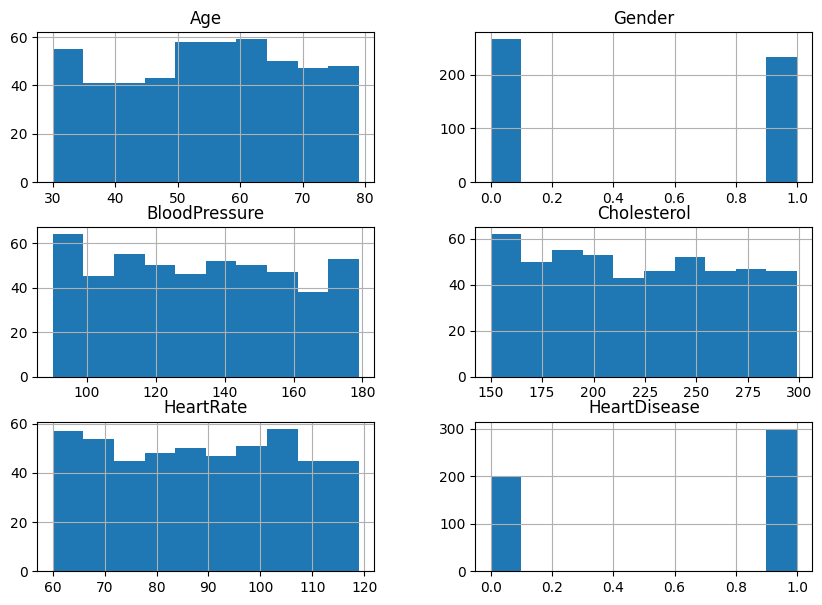

In [17]:
# Histograma de cada factor ya limpio

datos.hist(figsize=(10, 7))
plt.show()

Ahora sí salen los 6 histogramas porque ya todas las columnas son numéricas

Gender y HeartDisease salen como dos barras nada más porque solo valen 0 o 1

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?

In [18]:
datos.describe() # Media desviación mínimo máximo y cuartiles

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,1.000000


In [19]:
datos.median() # Mediana de cada variable

Age               55.0
Gender             0.0
BloodPressure    132.0
Cholesterol      221.0
HeartRate         89.0
HeartDisease       1.0
dtype: float64

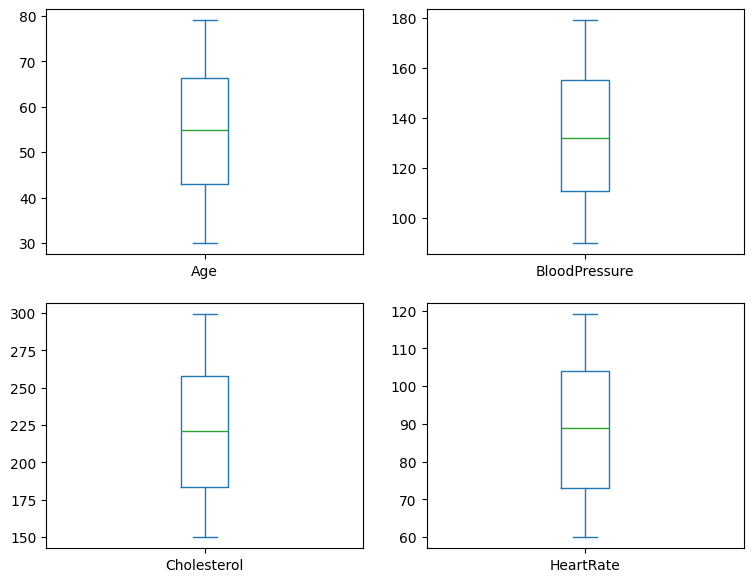

In [20]:
# Diagrama de caja de cada variable numérica

datos[["Age", "BloodPressure", "Cholesterol", "HeartRate"]].plot(kind="box", subplots=True, layout=(2, 2), figsize=(9, 7))
plt.show()

| | media | mediana | desv est | mínimo | máximo |
|:---|---|---|---|---|---|
| Age | 54.86 | 55 | 14.32 | 30 | 79 |
| BloodPressure | 132.87 | 132 | 26.42 | 90 | 179 |
| Cholesterol | 221.50 | 221 | 43.86 | 150 | 299 |
| HeartRate | 88.77 | 89 | 17.42 | 60 | 119 |

No hay ningún valor atípico. En las cuatro cajas los bigotes llegan hasta el mínimo y el máximo
y no aparece ni un punto suelto afuera

También se nota que en las cuatro variables la media y la mediana salen casi iguales y que la
caja queda justo en medio, que es otra señal de que los datos están repartidos parejo

Encuentra la siguiente información para las variables categóricas:
- tabla de frecuencias
- valores únicos

In [21]:
datos["Gender"].value_counts() # Frecuencias del sexo

Gender
0    266
1    234
Name: count, dtype: int64

In [22]:
datos["HeartDisease"].value_counts() # Frecuencias de la enfermedad

HeartDisease
1    300
0    200
Name: count, dtype: int64

In [23]:
# Valores únicos de las categóricas

print("Gender:", datos["Gender"].unique())
print("HeartDisease:", datos["HeartDisease"].unique())

Gender: [1 0]
HeartDisease: [1 0]


Las dos variables categóricas quedaron con puros 0 y 1

En Gender hay 266 mujeres y 234 hombres, está bastante parejo

En HeartDisease hay 300 pacientes con enfermedad y 200 sin ella, o sea 60 por ciento contra
40 por ciento

## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum